## Task 1
Done
link: https://www.linkedin.com/feed/update/urn:li:activity:7511674441844838400/

# Task 2: Automated Unstructured Web Scraping & Data Extraction Pipeline

## Objective
Build an automated pipeline that harvests data records from a remote web source, extracts the key fields, cleans them, and stores the result in a structured format.

## Approach
| Stage | What happens | Tools |
|---|---|---|
| 1. Fetch | Download listing pages with retries, backoff, and a polite delay | `requests` |
| 2. Parse | Isolate each raw listing block from the HTML | `BeautifulSoup` |
| 3. Extract | Pull out title, price, rating, stock status, stock quantity, and URL using text filtering (regex and class parsing) | `re` |
| 4. Clean | Remove whitespace artifacts (`\xa0`, newlines, repeated spaces, zero-width chars) and encoding glitches (`Â£`) | `re`, `str` methods |
| 5. Deduplicate | Drop repeated records by URL | `set` |
| 6. Store | Write the final dataset to a CSV file and a SQLite database | `csv`, `sqlite3` |

## Data Source
[books.toscrape.com](https://books.toscrape.com) is a public sandbox site built for scraping practice, so scraping it is explicitly allowed.

## Output
- `books.csv`: structured flat file
- `books.db`: SQLite database (`books` table, `url` as primary key)

In [3]:
import sqlite3
import pandas as pd

# Re-define the file paths so this cell works on its own.
csvPath = "books.csv"
dbPath = "books.db"

# Load the saved CSV again.
df = pd.read_csv(csvPath)

# Count how many rows were saved.
print("Total rows:", len(df))

# Check that no url appears twice.
print("Duplicate urls:", df["url"].duplicated().sum())

# Check for missing values in every column.
print("Missing values per column:")
print(df.isna().sum())

# Confirm the database holds the same number of rows as the CSV.
connection = sqlite3.connect(dbPath)
dbCount = connection.execute("SELECT COUNT(*) FROM books").fetchone()[0]
connection.close()
print("Rows in database:", dbCount)

Total rows: 100
Duplicate urls: 0
Missing values per column:
title          0
price_gbp      0
rating         0
in_stock       0
stock_qty    100
url            0
dtype: int64
Rows in database: 100


In [5]:
import csv
import logging
import re
import sqlite3
import time
from urllib.parse import urljoin

import requests
from bs4 import BeautifulSoup
import pandas as pd

# Settings that control how the scraper behaves.
startUrl = "https://books.toscrape.com/catalogue/page-1.html"
headers = {"User-Agent": "Mozilla/5.0 (compatible; DataPipelineBot/1.0)"}
maxPages = 5            # set to 0 to scrape every page
delaySeconds = 0.5      # pause between requests so we don't hammer the server
csvPath = "books.csv"
dbPath = "books.db"
columnNames = ["title", "price_gbp", "rating", "in_stock", "stock_qty", "url"]

# The site writes ratings as words, so this converts them to numbers.
ratingMap = {"One": 1, "Two": 2, "Three": 3, "Four": 4, "Five": 5}

# Logging prints progress messages while the scraper runs.
logging.basicConfig(level=logging.INFO, format="%(asctime)s %(levelname)s %(message)s", force=True)
log = logging.getLogger("pipeline")


# ---------- STEP 1: FETCH ----------
def fetchPage(session, url, retries=3):
    # Try the request a few times before giving up on this page.
    attempt = 1
    while attempt <= retries:
        try:
            response = session.get(url, headers=headers, timeout=15)

            # Raise an error for bad status codes like 404 or 500.
            response.raise_for_status()

            # Force utf-8 so the pound sign does not turn into garbage characters.
            response.encoding = "utf-8"
            return response.text

        except requests.RequestException as error:
            log.warning("Attempt %d of %d failed for %s: %s", attempt, retries, url, error)

            # Wait longer after each failure before trying again.
            time.sleep(2 ** attempt)
            attempt = attempt + 1

    log.error("Giving up on %s", url)
    return None


# ---------- STEP 2: CLEANING HELPERS ----------
def cleanText(text):
    # Return an empty string if the value is missing.
    if text is None:
        return ""

    # Replace non-breaking spaces and remove zero-width characters.
    text = text.replace("\xa0", " ").replace("\u200b", "")

    # Collapse tabs, newlines and repeated spaces into a single space.
    text = re.sub(r"\s+", " ", text)
    return text.strip()


def getPrice(rawText):
    # Pull the first number out of text like "£51.77".
    cleaned = cleanText(rawText)
    match = re.search(r"(\d+(?:[.,]\d+)?)", cleaned)

    if match is None:
        return None

    # Swap a comma for a dot so Python can convert it to a float.
    return float(match.group(1).replace(",", "."))


def getStock(rawText):
    # Lowercase everything so the text checks are easier.
    cleaned = cleanText(rawText).lower()

    # Check whether the item is in stock at all.
    inStock = "in stock" in cleaned

    # Look for the quantity inside brackets like "(22 available)".
    match = re.search(r"\((\d+)\s*available\)", cleaned)
    stockQty = None
    if match is not None:
        stockQty = int(match.group(1))

    return inStock, stockQty


def getRating(ratingTag):
    # Return nothing if the rating tag was not found.
    if ratingTag is None:
        return None

    # The rating word lives inside the tag's class list, like "star-rating Three".
    for className in ratingTag.get("class", []):
        if className in ratingMap:
            return ratingMap[className]

    return None


# ---------- STEP 3: PARSE ONE PAGE ----------
def parsePage(html, pageUrl):
    soup = BeautifulSoup(html, "html.parser")
    pageRecords = []

    # Every book on the page sits inside an article tag with this class.
    allBooks = soup.select("article.product_pod")

    for book in allBooks:
        # The title and link both live in the same anchor tag.
        linkTag = book.select_one("h3 a")
        if linkTag is None:
            continue

        priceTag = book.select_one("p.price_color")
        stockTag = book.select_one("p.instock.availability")
        ratingTag = book.select_one("p.star-rating")

        # Use the title attribute because the visible text is cut short.
        title = cleanText(linkTag.get("title") or linkTag.get_text())

        price = None
        if priceTag is not None:
            price = getPrice(priceTag.get_text())

        inStock = False
        stockQty = None
        if stockTag is not None:
            inStock, stockQty = getStock(stockTag.get_text())

        # Build the full link because the page only gives a relative one.
        fullUrl = urljoin(pageUrl, linkTag["href"])

        record = {
            "title": title,
            "price_gbp": price,
            "rating": getRating(ratingTag),
            "in_stock": inStock,
            "stock_qty": stockQty,
            "url": fullUrl,
        }
        pageRecords.append(record)

    # Find the link to the next page, if there is one.
    nextTag = soup.select_one("li.next a")
    nextUrl = None
    if nextTag is not None:
        nextUrl = urljoin(pageUrl, nextTag["href"])

    return pageRecords, nextUrl


# ---------- STEP 4: CRAWL ALL PAGES ----------
def crawlSite():
    session = requests.Session()
    currentUrl = startUrl
    pageCount = 0
    seenUrls = set()
    allRecords = []

    # Keep going until there is no next page or we hit the page limit.
    while currentUrl is not None and (maxPages == 0 or pageCount < maxPages):
        html = fetchPage(session, currentUrl)

        # Stop the crawl if a page could not be downloaded.
        if html is None:
            break

        pageRecords, nextUrl = parsePage(html, currentUrl)

        # Only keep records we have not seen before.
        newCount = 0
        for record in pageRecords:
            if record["url"] not in seenUrls:
                seenUrls.add(record["url"])
                allRecords.append(record)
                newCount = newCount + 1

        pageCount = pageCount + 1
        log.info("Page %d done: %d new records, %d total", pageCount, newCount, len(allRecords))

        currentUrl = nextUrl

        # Short pause before requesting the next page.
        time.sleep(delaySeconds)

    return allRecords


# ---------- STEP 5: SAVE THE DATA ----------
def saveToCsv(records, path):
    # Open the file with newline="" so Windows does not add blank rows.
    with open(path, "w", newline="", encoding="utf-8") as file:
        writer = csv.DictWriter(file, fieldnames=columnNames)
        writer.writeheader()
        writer.writerows(records)
    log.info("CSV saved to %s with %d rows", path, len(records))


def saveToDatabase(records, path):
    connection = sqlite3.connect(path)

    # Create the table on the first run, using url as the unique key.
    connection.execute("""
        CREATE TABLE IF NOT EXISTS books (
            url TEXT PRIMARY KEY,
            title TEXT NOT NULL,
            price_gbp REAL,
            rating INTEGER,
            in_stock INTEGER,
            stock_qty INTEGER
        )
    """)

    # Replace the old row if the same url is scraped again.
    connection.executemany(
        "INSERT OR REPLACE INTO books (url, title, price_gbp, rating, in_stock, stock_qty) "
        "VALUES (:url, :title, :price_gbp, :rating, :in_stock, :stock_qty)",
        records,
    )
    connection.commit()
    connection.close()
    log.info("Database saved to %s with %d rows", path, len(records))


# ---------- RUN THE PIPELINE ----------
scrapedRecords = crawlSite()

# Stop here with a clear message if nothing was collected.
assert len(scrapedRecords) > 0, "No data collected, check the network or the selectors"

saveToCsv(scrapedRecords, csvPath)
saveToDatabase(scrapedRecords, dbPath)

# Load the CSV back to confirm the saved file looks right.
df = pd.read_csv(csvPath)
print("Shape:", df.shape)
display(df.head(10))

2026-10-02 11:45:51,590 INFO Page 1 done: 20 new records, 20 total
2026-10-02 11:45:52,600 INFO Page 2 done: 20 new records, 40 total
2026-10-02 11:45:53,633 INFO Page 3 done: 20 new records, 60 total
2026-10-02 11:45:54,582 INFO Page 4 done: 20 new records, 80 total
2026-10-02 11:45:55,552 INFO Page 5 done: 20 new records, 100 total
2026-10-02 11:45:56,055 INFO CSV saved to books.csv with 100 rows
2026-10-02 11:45:56,064 INFO Database saved to books.db with 100 rows


Shape: (100, 6)


,title,price_gbp,rating,in_stock,stock_qty,url
0,A Light in the Attic,51.77,3,True,NaN,https://books.toscrape.com/catalogue/a-light-i...
1,Tipping the Velvet,53.74,1,True,NaN,https://books.toscrape.com/catalogue/tipping-t...
2,Soumission,50.10,1,True,NaN,https://books.toscrape.com/catalogue/soumissio...
3,Sharp Objects,47.82,4,True,NaN,https://books.toscrape.com/catalogue/sharp-obj...
4,Sapiens: A Brief History of Humankind,54.23,5,True,NaN,https://books.toscrape.com/catalogue/sapiens-a...
5,The Requiem Red,22.65,1,True,NaN,https://books.toscrape.com/catalogue/the-requi...
6,The Dirty Little Secrets of Getting Your Dream...,33.34,4,True,NaN,https://books.toscrape.com/catalogue/the-dirty...
7,The Coming Woman: A Novel Based on the Life of...,17.93,3,True,NaN,https://books.toscrape.com/catalogue/the-comin...
8,The Boys in the Boat: Nine Americans and Their...,22.60,4,True,NaN,https://books.toscrape.com/catalogue/the-boys-...
9,The Black Maria,52.15,1,True,NaN,https://books.toscrape.com/catalogue/the-black...


In [6]:
# Count how many rows were saved.
print("Total rows:", len(df))

# Check that no url appears twice.
print("Duplicate urls:", df["url"].duplicated().sum())

# Check for missing values in every column.
print("Missing values per column:")
print(df.isna().sum())

# Confirm the database holds the same number of rows as the CSV.
connection = sqlite3.connect(dbPath)
dbCount = connection.execute("SELECT COUNT(*) FROM books").fetchone()[0]
connection.close()
print("Rows in database:", dbCount)

Total rows: 100
Duplicate urls: 0
Missing values per column:
title          0
price_gbp      0
rating         0
in_stock       0
stock_qty    100
url            0
dtype: int64
Rows in database: 100


# Task 3: Unsupervised Machine Learning Customer Segmentation (Clustering)

## Objective
Group customers by purchasing behavior using unsupervised learning, without any predefined labels.

## Dataset
**Wholesale Customers** (UCI Machine Learning Repository): 440 customers with yearly spending on six product categories: Fresh, Milk, Grocery, Frozen, Detergents_Paper, Delicassen.

## Pipeline
| Step | Technique | Why |
|---|---|---|
| 1. Ingest | `pandas` | Load and inspect the data |
| 2. Preprocess | Log transform + `StandardScaler` | Spending is heavily right-skewed, and K-Means is distance-based, so scale matters |
| 3. Reduce dimensions | PCA | Remove redundancy between correlated columns and allow 2D visualization |
| 4. Choose k | Elbow Method (silhouette as a cross-check) | Find the cluster count where extra clusters stop paying off |
| 5. Cluster | K-Means | Assign each customer to a segment |
| 6. Interpret | Segment profiling and visualization | Turn cluster numbers into business meaning |

## Note on preprocessing
`Channel` and `Region` are category codes, not spending amounts, so they are excluded from clustering.

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Fixed seed so the results are the same every time the notebook runs.
randomSeed = 42
np.random.seed(randomSeed)

# Public UCI dataset with yearly spending of 440 wholesale customers.
dataUrl = "https://archive.ics.uci.edu/ml/machine-learning-databases/00292/Wholesale%20customers%20data.csv"


def makeBackupData():
    # Build fake customers with three spending habits, used only if the download fails.
    rowsPerGroup = 150
    groupMeans = [
        [9.5, 6.0, 6.5, 7.0, 5.0, 5.5],
        [7.5, 9.0, 9.5, 6.0, 8.5, 6.5],
        [8.0, 7.5, 7.5, 8.5, 6.0, 8.0],
    ]
    allRows = []
    i = 0
    while i < len(groupMeans):
        groupRows = np.random.normal(groupMeans[i], 0.7, size=(rowsPerGroup, 6))
        allRows.append(np.exp(groupRows))
        i = i + 1
    backup = pd.DataFrame(np.vstack(allRows).astype(int),
                          columns=["Fresh", "Milk", "Grocery", "Frozen", "Detergents_Paper", "Delicassen"])
    backup.insert(0, "Region", 3)
    backup.insert(0, "Channel", 1)
    return backup


# Try the real dataset first and fall back only if there is no internet.
try:
    rawData = pd.read_csv(dataUrl)
    print("Loaded the real UCI dataset.")
except Exception as error:
    print("Download failed:", error)
    print("WARNING: using synthetic backup data, do not submit results from this.")
    rawData = makeBackupData()

print("Shape:", rawData.shape)
display(rawData.head())

# Check column types and missing values before touching anything.
print("\nMissing values per column:")
print(rawData.isna().sum())
display(rawData.describe().round(1))

Loaded the real UCI dataset.
Shape: (440, 8)


,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,2,3,12669,9656,7561,214,2674,1338
1,2,3,7057,9810,9568,1762,3293,1776
2,2,3,6353,8808,7684,2405,3516,7844
3,1,3,13265,1196,4221,6404,507,1788
4,2,3,22615,5410,7198,3915,1777,5185



Missing values per column:
Channel             0
Region              0
Fresh               0
Milk                0
Grocery             0
Frozen              0
Detergents_Paper    0
Delicassen          0
dtype: int64


,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
count,440.0,440.0,440.0,440.0,440.0,440.0,440.0,440.0
mean,1.3,2.5,12000.3,5796.3,7951.3,3071.9,2881.5,1524.9
std,0.5,0.8,12647.3,7380.4,9503.2,4854.7,4767.9,2820.1
min,1.0,1.0,3.0,55.0,3.0,25.0,3.0,3.0
25%,1.0,2.0,3127.8,1533.0,2153.0,742.2,256.8,408.2
50%,1.0,3.0,8504.0,3627.0,4755.5,1526.0,816.5,965.5
75%,2.0,3.0,16933.8,7190.2,10655.8,3554.2,3922.0,1820.2
max,2.0,3.0,112151.0,73498.0,92780.0,60869.0,40827.0,47943.0


## Step 2: Standardization
The spending columns are heavily right-skewed: a few huge customers dominate each column. K-Means uses distances, so those outliers would pull the clusters toward themselves. Two fixes are applied:
1. **Log transform** (`log1p`) to reduce skew.
2. **StandardScaler** so every feature has mean 0 and standard deviation 1.

In [10]:
# Channel and Region are category codes, so only the spending columns are clustered.
spendColumns = ["Fresh", "Milk", "Grocery", "Frozen", "Detergents_Paper", "Delicassen"]
features = rawData[spendColumns].copy()

# Skewness shows how lopsided each column is before any fixing.
skewBefore = features.skew()

# log1p squeezes the huge outliers so they do not dominate the distance calculation.
logFeatures = np.log1p(features)
skewAfter = logFeatures.skew()

skewTable = pd.DataFrame({"skew_before": skewBefore, "skew_after_log": skewAfter}).round(2)
display(skewTable)

# StandardScaler gives every column mean 0 and standard deviation 1.
scaler = StandardScaler()
scaledData = scaler.fit_transform(logFeatures)

# Quick check that the scaling worked.
print("Column means after scaling:", scaledData.mean(axis=0).round(2))
print("Column stds after scaling: ", scaledData.std(axis=0).round(2))

,skew_before,skew_after_log
Fresh,2.56,-1.58
Milk,4.05,-0.22
Grocery,3.59,-0.67
Frozen,5.91,-0.35
Detergents_Paper,3.63,-0.24
Delicassen,11.15,-1.09


Column means after scaling: [ 0. -0. -0.  0. -0. -0.]
Column stds after scaling:  [1. 1. 1. 1. 1. 1.]


## Step 3: Principal Component Analysis (PCA)
PCA rewrites the six correlated columns as uncorrelated components, ordered by how much variance they capture. I keep the smallest number of components that explains at least **85%** of the total variance. The loadings table shows which original columns drive each component.

Components kept: 4 -> variance explained: 92.1 %


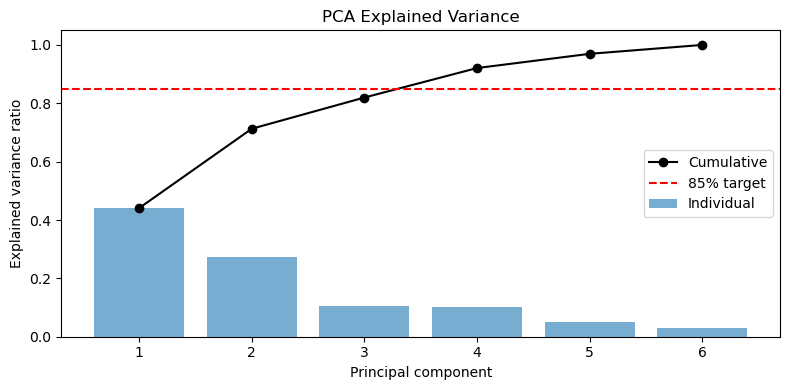

,PC1,PC2,PC3,PC4
Fresh,-0.11,0.59,-0.64,-0.48
Milk,0.54,0.13,-0.07,0.06
Grocery,0.57,-0.01,-0.13,0.10
Frozen,-0.14,0.59,-0.02,0.79
Detergents_Paper,0.55,-0.07,-0.20,0.08
Delicassen,0.21,0.53,0.73,-0.35


In [11]:
# Fit PCA with every component first so we can see how much variance each one holds.
pcaFull = PCA(random_state=randomSeed)
pcaFull.fit(scaledData)

explained = pcaFull.explained_variance_ratio_
cumulative = np.cumsum(explained)
componentNumbers = np.arange(1, len(explained) + 1)

# Keep the smallest number of components that explains at least 85% of the variance.
varianceTarget = 0.85
nComponents = int(np.argmax(cumulative >= varianceTarget)) + 1
print("Components kept:", nComponents, "-> variance explained:", round(cumulative[nComponents - 1] * 100, 1), "%")

# Plot individual and cumulative variance side by side.
plt.figure(figsize=(8, 4))
plt.bar(componentNumbers, explained, alpha=0.6, label="Individual")
plt.plot(componentNumbers, cumulative, marker="o", color="black", label="Cumulative")
plt.axhline(varianceTarget, color="red", linestyle="--", label="85% target")
plt.xlabel("Principal component")
plt.ylabel("Explained variance ratio")
plt.title("PCA Explained Variance")
plt.legend()
plt.tight_layout()
plt.show()

# Refit with only the components we decided to keep.
pca = PCA(n_components=nComponents, random_state=randomSeed)
pcaData = pca.fit_transform(scaledData)

# Loadings show which original columns drive each component.
loadings = pd.DataFrame(pca.components_.T, index=spendColumns,
                        columns=["PC" + str(n) for n in range(1, nComponents + 1)]).round(2)
display(loadings)

## Step 4: Choosing the Number of Clusters (Elbow Method)
K-Means is run for k = 1 to 10 and the inertia (within-cluster sum of squares) is recorded. Inertia always drops as k grows, so the useful signal is the **elbow**, where the improvement flattens. The elbow is found by measuring which point sits farthest from the straight line joining the first and last points. The **silhouette score** is plotted as a cross-check, since reading an elbow by eye is subjective.

Elbow suggests k = 3
Best silhouette score at k = 2


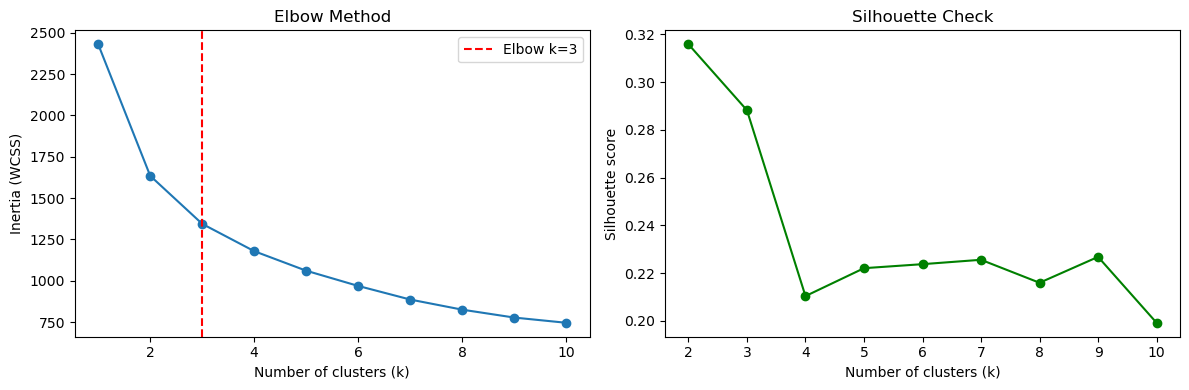

In [12]:
# Try 1 to 10 clusters and record how tight the clusters are each time.
kValues = list(range(1, 11))
inertiaList = []
silhouetteList = []

for k in kValues:
    model = KMeans(n_clusters=k, n_init=10, random_state=randomSeed)
    model.fit(pcaData)
    inertiaList.append(model.inertia_)

    # Silhouette needs at least 2 clusters, so k=1 gets an empty slot.
    if k >= 2:
        silhouetteList.append(silhouette_score(pcaData, model.labels_))
    else:
        silhouetteList.append(np.nan)

# Elbow point = the k whose point sits farthest from the straight line joining the first and last points.
firstPoint = np.array([kValues[0], inertiaList[0]])
lastPoint = np.array([kValues[-1], inertiaList[-1]])
lineVector = (lastPoint - firstPoint) / np.linalg.norm(lastPoint - firstPoint)

distances = []
for index in range(len(kValues)):
    point = np.array([kValues[index], inertiaList[index]])
    fromFirst = point - firstPoint
    # Remove the part along the line, what is left is the distance from the line.
    offLine = fromFirst - np.dot(fromFirst, lineVector) * lineVector
    distances.append(np.linalg.norm(offLine))

elbowK = kValues[int(np.argmax(distances))]
print("Elbow suggests k =", elbowK)

# Silhouette is a second opinion because the elbow is a judgement call.
bestSilhouetteK = kValues[int(np.nanargmax(silhouetteList))]
print("Best silhouette score at k =", bestSilhouetteK)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(kValues, inertiaList, marker="o")
axes[0].axvline(elbowK, color="red", linestyle="--", label="Elbow k=" + str(elbowK))
axes[0].set_xlabel("Number of clusters (k)")
axes[0].set_ylabel("Inertia (WCSS)")
axes[0].set_title("Elbow Method")
axes[0].legend()

axes[1].plot(kValues, silhouetteList, marker="o", color="green")
axes[1].set_xlabel("Number of clusters (k)")
axes[1].set_ylabel("Silhouette score")
axes[1].set_title("Silhouette Check")

plt.tight_layout()
plt.show()

## Step 5: Fit the K-Means Model
The final model uses the k chosen by the Elbow Method and is fitted on the PCA-reduced data. `n_init=10` runs K-Means from 10 random starts and keeps the best result, which avoids a bad initialization.

In [13]:
# Final cluster count comes from the elbow, as the task asks.
finalK = elbowK

kmeans = KMeans(n_clusters=finalK, n_init=10, random_state=randomSeed)
clusterLabels = kmeans.fit_predict(pcaData)

segmented = rawData.copy()
segmented["Segment"] = clusterLabels

print("Final k:", finalK)
print("Silhouette score:", round(silhouette_score(pcaData, clusterLabels), 3))
print("\nCustomers per segment:")
print(segmented["Segment"].value_counts().sort_index())

Final k: 3
Silhouette score: 0.288

Customers per segment:
Segment
0     82
1    215
2    143
Name: count, dtype: int64


## Step 6: Visualizing the Segments
The left plot shows every customer on the first two principal components, coloured by segment, with centroids marked. The right plot shows how large each segment is.

2026-10-02 11:57:08,273 INFO Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-10-02 11:57:08,274 INFO Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


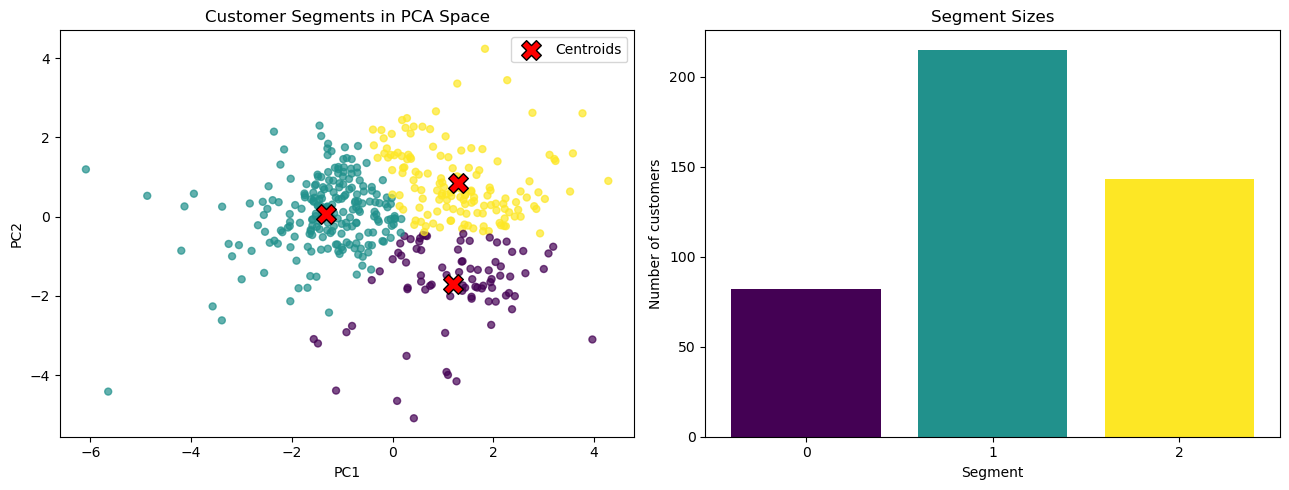

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left plot: every customer on the first two principal components, coloured by segment.
scatter = axes[0].scatter(pcaData[:, 0], pcaData[:, 1], c=clusterLabels, cmap="viridis", s=25, alpha=0.7)
axes[0].scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1],
                c="red", marker="X", s=200, edgecolor="black", label="Centroids")
axes[0].set_xlabel("PC1")
axes[0].set_ylabel("PC2")
axes[0].set_title("Customer Segments in PCA Space")
axes[0].legend()

# Right plot: how many customers fall in each segment.
segmentCounts = segmented["Segment"].value_counts().sort_index()
axes[1].bar(segmentCounts.index.astype(str), segmentCounts.values, color=plt.cm.viridis(np.linspace(0, 1, finalK)))
axes[1].set_xlabel("Segment")
axes[1].set_ylabel("Number of customers")
axes[1].set_title("Segment Sizes")

plt.tight_layout()
plt.show()

## Step 7: Segment Profiles
Clusters are only useful if they can be described. The table shows average spending per segment in original units. The heatmap divides each value by the overall average, so **above 1.0 means the segment over-spends** on that category and **below 1.0 means it under-spends**.

,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
Segment,,,,,,
0,2997.0,7045.0,12505.0,608.0,5511.0,797.0
1,12032.0,2068.0,2526.0,3237.0,422.0,905.0
2,17116.0,10685.0,13497.0,4236.0,5072.0,2874.0


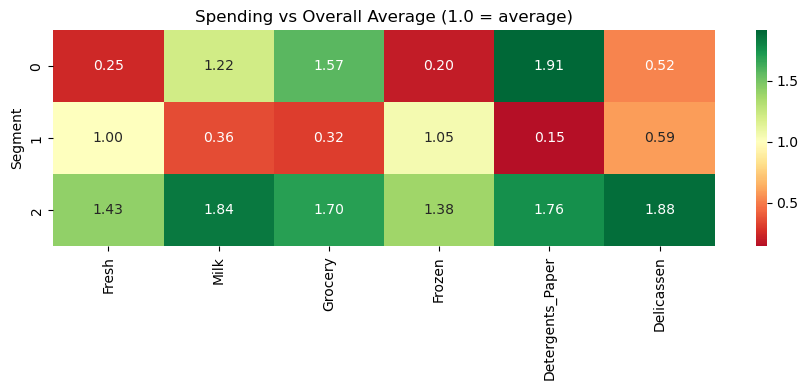

Saved customer_segments.csv with 440 rows


In [15]:
# Average spending per segment in the original money units.
profile = segmented.groupby("Segment")[spendColumns].mean().round(0)
display(profile)

# Dividing by the overall average shows what each segment over or under spends on.
overallMean = segmented[spendColumns].mean()
relativeProfile = profile / overallMean

plt.figure(figsize=(9, 4))
sns.heatmap(relativeProfile, annot=True, fmt=".2f", cmap="RdYlGn", center=1)
plt.title("Spending vs Overall Average (1.0 = average)")
plt.ylabel("Segment")
plt.tight_layout()
plt.show()

# Save the labelled customers for later use.
segmented.to_csv("customer_segments.csv", index=False)
print("Saved customer_segments.csv with", len(segmented), "rows")

## Conclusion
- **Clusters found:** k = __ (Elbow Method), silhouette score = __
- **PCA:** __ components retained, explaining __% of variance
- **Segment 0:** [describe from the heatmap, e.g. "high Grocery and Detergents_Paper, low Fresh"]
- **Segment 1:** [...]
- **Business use:** [e.g. targeted promotions, inventory planning per segment]
- **Limitations:** K-Means assumes roughly spherical clusters of similar size, and the result depends on the log transform and the 85% PCA cutoff.